# Eksplorasi: CNN dengan Backbone ResNet-50 (S2-resnet)

**Input:** Citra X-ray dada (224x224 piksel, 3 channel), sama seperti S2.

**Arsitektur:** ResNet-50 (bobot ImageNet, TIDAK ada padanan CheXNet untuk arsitektur ini) sebagai pengganti DenseNet-121.

**PENTING - bukan perbandingan apple-to-apple:** S2 dan S2-attn memakai bobot CheXNet (pretrained khusus NIH ChestX-ray14), sedangkan ResNet-50 di sini hanya bisa memakai ImageNet generik karena tidak ada bobot CheXNet untuk arsitektur ini.

**Motivasi:** Tang et al. 2025 (JMIR Med Inform, paper paling mirip topik ini - fusi citra+tabular klinis) memakai ResNet-50 sebagai backbone dan mencapai AUC 0.975. Literatur juga menunjukkan attention module memberi kenaikan AUC terbesar khusus pada backbone ResNet (Imran et al. 2026, Scientific Reports: Attention-ResNet101 0.853->0.872, sementara EfficientNet-B0/B3 'minimal change'). Eksperimen ini menguji ResNet-50 polos dulu (apple-to-apple dengan S2-eff, sama-sama ImageNet tanpa attention) sebelum mempertimbangkan menambah attention.

**Catatan:** ini eksperimen eksploratif (bukan skenario resmi proposal). Checkpoint dan hasil disimpan terpisah (`model_s2-resnet_best.pt`, `results_s2resnet.csv`).

## 1. Setup & Load Dataset

In [1]:
import sys
sys.path.insert(0, r"D:\TA\nih-multimodal")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.amp import autocast, GradScaler
from tqdm.auto import tqdm
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    confusion_matrix, roc_curve, accuracy_score
)

from configs.config import cfg
from src.models.architectures import ImageCNNResNet
from src.data.dataset import create_dataloaders
from src.evaluation.stats import delong_test, bootstrap_auc_ci

torch.manual_seed(cfg.train.seed)
np.random.seed(cfg.train.seed)

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = cfg.paths.figures_dir
CKPT_DIR = cfg.paths.checkpoint_dir
TABLES_DIR = cfg.paths.project_root / "results" / "tables"
for d in [SAVE_DIR, CKPT_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Device  : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"AMP     : {cfg.train.use_amp}")
print(f"Grad Accum Steps: {cfg.train.gradient_accumulation_steps} "
      f"(effective batch = {cfg.train.batch_size * cfg.train.gradient_accumulation_steps})")

Device  : cuda
GPU     : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM    : 6.4 GB
AMP     : True
Grad Accum Steps: 2 (effective batch = 32)


In [2]:
# create_dataloaders() menangani: image index, metadata, patient-level split, transforms, scaler
train_loader, val_loader, test_loader, scaler, pos_weights = create_dataloaders(
    batch_size=cfg.train.batch_size
)

print("\nDataloader siap.")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

# Hitung pos_weight binary dari train set
y_train_all = []
for batch in train_loader:
    y_train_all.append(batch["label_binary"].numpy())
y_train_all = np.concatenate(y_train_all)
pos_ratio = y_train_all.mean()
pw_binary = torch.tensor([(1 - pos_ratio) / pos_ratio], dtype=torch.float32).to(DEVICE)
print(f"\nPos ratio (train binary) : {pos_ratio:.3f}")
print(f"pos_weight               : {pw_binary.item():.3f}")

[Data] Indexed 112120 images across 12 directories


[Data] Loaded metadata: 112120 samples, 30805 patients
[Data] Split — Train: 77994 | Val: 8530 | Test: 25596

Dataloader siap.
Train batches : 4874
Val batches   : 267
Test batches  : 800



Pos ratio (train binary) : 0.417
pos_weight               : 1.400


## 2. Model, Optimizer, Scheduler

In [3]:
# S2-resnet: EfficientNet-B0 backbone (ImageNet pretrain), binary output
model = ImageCNNResNet(num_classes=1).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pw_binary)
scaler_amp = GradScaler('cuda', enabled=cfg.train.use_amp)

# Differential learning rate: backbone lebih kecil dari head/projection
optimizer = torch.optim.AdamW([
    {"params": model.branch.features.parameters(),   "lr": cfg.train.lr_backbone},
    {"params": model.branch.projection.parameters(), "lr": cfg.train.lr_fusion},
    {"params": model.classifier.parameters(),        "lr": cfg.train.lr_fusion},
], weight_decay=cfg.train.weight_decay)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=cfg.train.scheduler_patience,
    factor=cfg.train.scheduler_factor
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model          : ResNet-50 (ImageNet pretrain) (S2-resnet Binary)")
print(f"Total params   : {total_params:,}")
print(f"Trainable      : {trainable_params:,}")
print(f"LR backbone    : {cfg.train.lr_backbone}")
print(f"LR head        : {cfg.train.lr_fusion}")

Model          : ResNet-50 (ImageNet pretrain) (S2-resnet Binary)
Total params   : 24,558,657
Trainable      : 17,133,569
LR backbone    : 0.0001
LR head        : 0.0005


## 3. Training Loop (dengan progress bar tqdm)

In [4]:
ACCUM_STEPS = cfg.train.gradient_accumulation_steps


def train_epoch(model, loader, criterion, optimizer, scaler_amp, device, accum_steps, epoch_num):
    model.train()
    total_loss, n = 0.0, 0
    all_probs, all_labels = [], []
    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(loader, desc=f"Epoch {epoch_num} [train]", leave=False)
    for step, batch in enumerate(pbar):
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label_binary"].to(device, non_blocking=True)

        with autocast('cuda', enabled=cfg.train.use_amp):
            logits = model(image=images).squeeze(1)
            loss   = criterion(logits, labels) / accum_steps

        scaler_amp.scale(loss).backward()

        if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
            scaler_amp.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler_amp.step(optimizer)
            scaler_amp.update()
            optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * accum_steps * len(labels)
        n += len(labels)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.cpu().numpy())

        if step % 20 == 0:
            pbar.set_postfix(loss=f"{total_loss/max(n,1):.4f}")

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    return total_loss / n, roc_auc_score(all_labels, all_probs)


@torch.no_grad()
def evaluate(model, loader, criterion, device, desc="eval"):
    model.eval()
    total_loss, n = 0.0, 0
    all_probs, all_labels = [], []

    for batch in tqdm(loader, desc=desc, leave=False):
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label_binary"].to(device, non_blocking=True)

        with autocast('cuda', enabled=cfg.train.use_amp):
            logits = model(image=images).squeeze(1)
            loss   = criterion(logits, labels)

        total_loss += loss.item() * len(labels)
        n += len(labels)
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    return total_loss / n, roc_auc_score(all_labels, all_probs), all_probs, all_labels


# ── Main training loop ──
CKPT_PATH = CKPT_DIR / "model_s2-resnet_best.pt"
history   = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": []}
best_val_auc     = 0.0
patience_counter = 0
t0 = time.time()

print(f"{'Epoch':>5} {'Train Loss':>12} {'Train AUC':>10} {'Val Loss':>10} {'Val AUC':>9} {'LR (bb)':>10} {'Time':>7}")
print("-" * 72)

for epoch in range(1, cfg.train.num_epochs + 1):
    ep_start = time.time()

    train_loss, train_auc = train_epoch(
        model, train_loader, criterion, optimizer, scaler_amp, DEVICE, ACCUM_STEPS, epoch
    )
    val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion, DEVICE, desc=f"Epoch {epoch} [val]")

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_auc"].append(train_auc)
    history["val_auc"].append(val_auc)

    scheduler.step(val_auc)
    current_lr = optimizer.param_groups[0]["lr"]
    ep_time    = time.time() - ep_start

    flag = ""
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), CKPT_PATH)
        patience_counter = 0
        flag = " \u2713"
    else:
        patience_counter += 1

    print(f"{epoch:>5} {train_loss:>12.4f} {train_auc:>10.4f} "
          f"{val_loss:>10.4f} {val_auc:>9.4f} {current_lr:>10.2e} "
          f"{ep_time:>6.1f}s{flag}")

    if patience_counter >= cfg.train.early_stop_patience:
        print(f"\nEarly stopping di epoch {epoch} (patience={cfg.train.early_stop_patience})")
        break

total_time = time.time() - t0
print(f"\nTraining selesai dalam {total_time/60:.1f} menit")
print(f"Best Val AUC : {best_val_auc:.4f}")
print(f"Model tersimpan: {CKPT_PATH}")

Epoch   Train Loss  Train AUC   Val Loss   Val AUC    LR (bb)    Time
------------------------------------------------------------------------


Epoch 1 [train]:   0%|          | 0/4874 [00:00<?, ?it/s]

Epoch 1 [val]:   0%|          | 0/267 [00:22<?, ?it/s]

    1       0.7356     0.7061     0.7048    0.7428   1.00e-04  722.0s ✓


Epoch 2 [train]:   0%|          | 0/4874 [00:00<?, ?it/s]

...

Epoch 17 [val]:   0%|          | 0/267 [00:00<?, ?it/s]

   17       0.6276     0.8052     0.7155    0.7533   2.50e-05  797.1s


Epoch 18 [train]:   0%|          | 0/4874 [00:00<?, ?it/s]

Epoch 18 [val]:   0%|          | 0/267 [00:00<?, ?it/s]

   18       0.6225     0.8085     0.7356    0.7477   2.50e-05  803.4s

Early stopping di epoch 18 (patience=7)

Training selesai dalam 215.5 menit
Best Val AUC : 0.7621
Model tersimpan: D:\TA\nih-multimodal\results\checkpoints\model_s2-resnet_best.pt


## 4. Training Curves

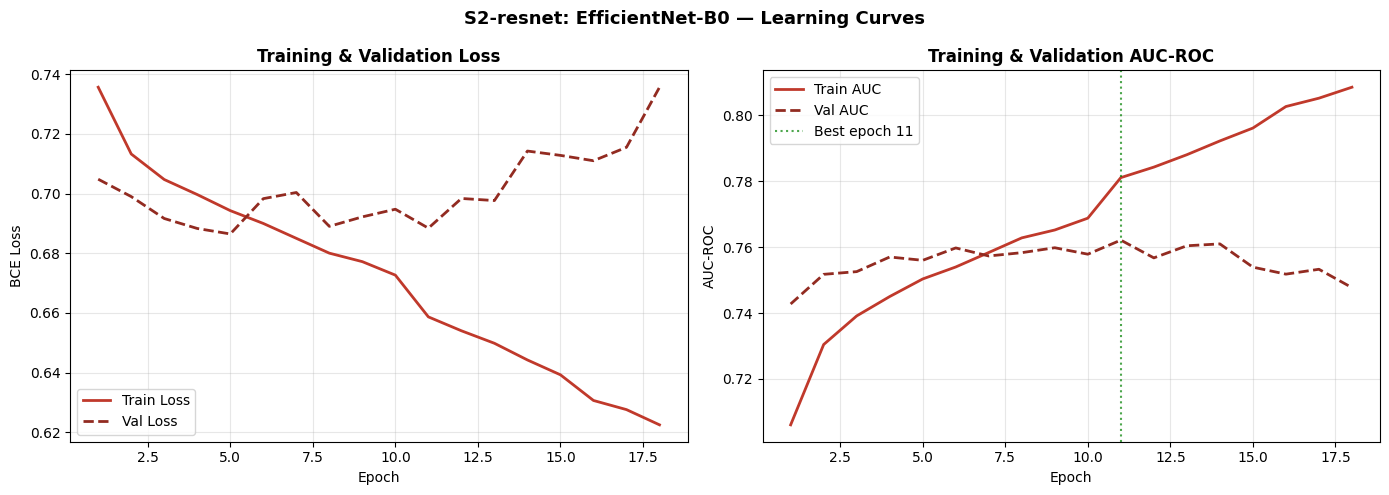

Disimpan → results/figures/s2resnet_training_curves.png


In [5]:
epochs_ran = range(1, len(history["train_loss"]) + 1)
best_ep    = np.argmax(history["val_auc"]) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, history["train_loss"], label="Train Loss", color="#c0392b", linewidth=2)
axes[0].plot(epochs_ran, history["val_loss"],   label="Val Loss",   color="#922b21", linewidth=2, linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Training & Validation Loss", fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history["train_auc"], label="Train AUC", color="#c0392b", linewidth=2)
axes[1].plot(epochs_ran, history["val_auc"],   label="Val AUC",   color="#922b21", linewidth=2, linestyle="--")
axes[1].axvline(best_ep, color="green", linestyle=":", alpha=0.7, label=f"Best epoch {best_ep}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC-ROC")
axes[1].set_title("Training & Validation AUC-ROC", fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("S2-resnet: EfficientNet-B0 — Learning Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "s2resnet_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan \u2192 results/figures/s2resnet_training_curves.png")

## 5. Evaluasi pada Test Set

In [6]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
_, test_auc, test_probs, test_labels = evaluate(model, test_loader, criterion, DEVICE, desc="test")

test_preds = (test_probs >= 0.5).astype(int)

acc      = accuracy_score(test_labels, test_preds)
f1       = f1_score(test_labels, test_preds, average="binary")
f1_macro = f1_score(test_labels, test_preds, average="macro")
auc      = roc_auc_score(test_labels, test_probs)

print("=" * 55)
print("HASIL EVALUASI S2-resnet: EfficientNet-B0")
print("=" * 55)
print(f"Accuracy       : {acc:.4f}")
print(f"F1-Score (bin) : {f1:.4f}")
print(f"F1-Score (mac) : {f1_macro:.4f}")
print(f"AUC-ROC        : {auc:.4f}")
print()
print(classification_report(test_labels, test_preds, target_names=["Normal", "Abnormal"]))

C:\Users\ASUS\AppData\Local\Temp\ipykernel_520\393361233.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE)

test:   0%|          | 0/800 [00:33<?, ?it/s]

HASIL EVALUASI S2-resnet: EfficientNet-B0
Accuracy       : 0.7033
F1-Score (bin) : 0.7811
F1-Score (mac) : 0.6604
AUC-ROC        : 0.7130

              precision    recall  f1-score   support

      Normal       0.67      0.45      0.54      9861
    Abnormal       0.71      0.86      0.78     15735

    accuracy                           0.70     25596
   macro avg       0.69      0.66      0.66     25596
weighted avg       0.70      0.70      0.69     25596



## 6. Bandingkan dengan S2 Baseline (DeLong Test)

In [7]:
s2_baseline_path = TABLES_DIR / "predictions_s2.csv"

if s2_baseline_path.exists():
    s2_df = pd.read_csv(s2_baseline_path)
    s2_probs  = s2_df["prob_s2"].to_numpy()
    s2_labels = s2_df["true_label"].to_numpy()

    if len(s2_labels) == len(test_labels) and (s2_labels == test_labels.astype(int)).all():
        ci_base = bootstrap_auc_ci(s2_probs, s2_labels)
        ci_attn = bootstrap_auc_ci(test_probs, test_labels)

        print("=" * 60)
        print("S2-resnet (EfficientNet-B0) vs S2 baseline (DenseNet-121+CheXNet)")
        print("=" * 60)
        print(f"S2 baseline : AUC={ci_base['auc']:.4f}  95% CI=[{ci_base['ci_low']:.4f}, {ci_base['ci_high']:.4f}]")
        print(f"S2-resnet     : AUC={ci_attn['auc']:.4f}  95% CI=[{ci_attn['ci_low']:.4f}, {ci_attn['ci_high']:.4f}]")

        d = delong_test(test_probs, s2_probs, test_labels)
        sig = "SIGNIFICANT (p<0.05)" if d["p_value"] < 0.05 else "not significant (p>=0.05)"
        print(f"\nDeLong S2-resnet vs S2: dAUC={d['delta_auc']:+.4f}  z={d['z']:.3f}  p={d['p_value']:.4f}  -> {sig}")
    else:
        print("[Warn] Test set S2 baseline tidak sejajar dengan S2-resnet \u2014 lewati perbandingan DeLong.")
else:
    print(f"[Warn] Tidak ada baseline predictions di {s2_baseline_path} \u2014 lewati perbandingan.")

S2-resnet (EfficientNet-B0) vs S2 baseline (DenseNet-121+CheXNet)
S2 baseline : AUC=0.7442  95% CI=[0.7379, 0.7506]
S2-resnet     : AUC=0.7130  95% CI=[0.7065, 0.7195]

DeLong S2-resnet vs S2: dAUC=-0.0312  z=-13.775  p=0.0000  -> SIGNIFICANT (p<0.05)


## 7. Confusion Matrix & ROC Curve

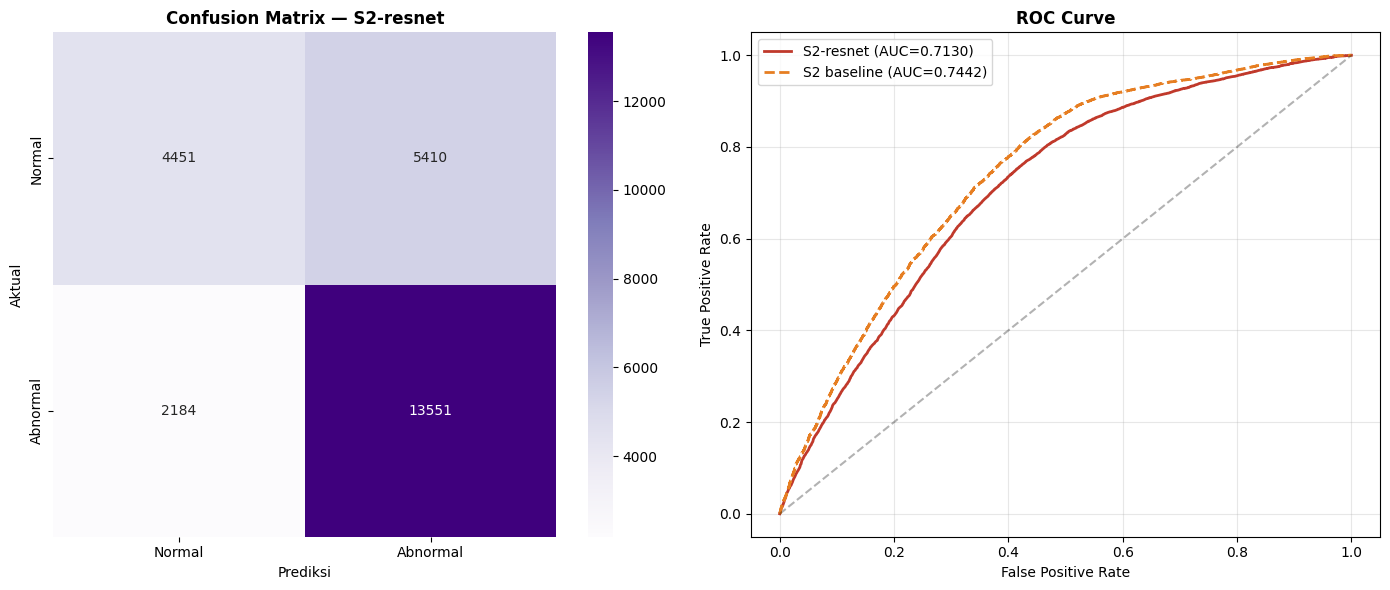

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", ax=axes[0],
            xticklabels=["Normal", "Abnormal"], yticklabels=["Normal", "Abnormal"])
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Aktual")
axes[0].set_title("Confusion Matrix — S2-resnet", fontweight="bold")

fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[1].plot(fpr, tpr, color="#c0392b", linewidth=2, label=f"S2-resnet (AUC={auc:.4f})")
if s2_baseline_path.exists() and len(s2_labels) == len(test_labels):
    fpr_b, tpr_b, _ = roc_curve(s2_labels, s2_probs)
    axes[1].plot(fpr_b, tpr_b, color="#e67e22", linewidth=2, linestyle="--", label=f"S2 baseline (AUC={ci_base['auc']:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / "s2resnet_confusion_roc.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Simpan Hasil

In [9]:
results_s2attn = {
    "Skenario"    : "S2-resnet",
    "Model"       : "ResNet-50 (ImageNet pretrain)",
    "Input"       : "Gambar X-ray (224\u00d7224)",
    "Accuracy"    : round(acc, 4),
    "F1 (Binary)" : round(f1, 4),
    "F1 (Macro)"  : round(f1_macro, 4),
    "AUC-ROC"     : round(auc, 4),
    "Best Epoch"  : best_ep,
    "Best Val AUC": round(best_val_auc, 4),
}

pd.DataFrame([results_s2attn]).to_csv(TABLES_DIR / "results_s2resnet.csv", index=False)

pd.DataFrame({
    "true_label": test_labels.astype(int),
    "prob_s2resnet": test_probs,
    "pred_s2resnet": test_preds,
}).to_csv(TABLES_DIR / "predictions_s2resnet.csv", index=False)

print("Disimpan:")
print(f"  {TABLES_DIR / 'results_s2resnet.csv'}")
print(f"  {TABLES_DIR / 'predictions_s2resnet.csv'}")
print(f"  Model checkpoint: {CKPT_PATH}")
print()
print("CATATAN: hasil ini eksploratif (bukan skenario resmi proposal).")
print("Bandingkan AUC S2-resnet di atas dengan S2 baseline (0.7442) dan cek")
print("signifikansi DeLong di cell sebelumnya sebelum memutuskan apakah")
print("EfficientNet worth dilaporkan (ingat: bukan perbandingan apple-to-apple, beda pretrain).")

Disimpan:
  D:\TA\nih-multimodal\results\tables\results_s2resnet.csv
  D:\TA\nih-multimodal\results\tables\predictions_s2resnet.csv
  Model checkpoint: D:\TA\nih-multimodal\results\checkpoints\model_s2-resnet_best.pt

CATATAN: hasil ini eksploratif (bukan skenario resmi proposal).
Bandingkan AUC S2-resnet di atas dengan S2 baseline (0.7442) dan cek
signifikansi DeLong di cell sebelumnya sebelum memutuskan apakah
EfficientNet worth dilaporkan (ingat: bukan perbandingan apple-to-apple, beda pretrain).
